# PREVISIONE POPOLARITÀ CANZONI

## Descrizione del problema

obiettivo

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Caricamento dei dati
Questo dataset, ottenuto da Kaggle, contiene un insieme di brani Spotify, appartenenti a diversi generi musicali, corredati delle rispettive caratteristiche audio.

### Feature del Dataset
- `track_id`: Spotify ID del brano
- `artists`: artista o gruppo che esegue il brano
- `album_name`: nome dell’album in cui è contenuto il brano
- `track_name`: titolo della traccia
- `duration_ms`: durata del brano in millisecondi
- `explicit`: indica se il brano contiene contenuti espliciti (True/False)
- `danceability`: misura quanto il brano è "ballabile"
- `energy`: livello di intensità e di energia del brano
- `key`: tonalità musicale del brano (codificata numericamente: 0=C, 1=C#/Db, 2=D,...)
- `loudness`: volume medio del brano in decibel
- `mode`: modalità musicale (maggiore = 1, minore = 0)
- `speechiness`: presenza di parlato nel brano
- `acousticness`: probabilità che il brano sia acustico
- `instrumentalness`: probabilità che il brano sia strumentale (senza voce)
- `liveness`: probabilità che il brano sia registrato dal vivo
- `valence`: misura della positività/“felicità” del brano
- `tempo`: velocità del brano in BPM (battiti per minuto)
- `time_signature`: numero di battiti per misura (valori compresi tra 3 (3/4) e 7 (7/4))
- `track_genre`: genere musicale del brano

La variabile target da predirre è `popularity`, l'indice di popolarità del brano (di solito da 0 a 100)

In [11]:
import os.path
file = "dataset.csv";
if not os.path.exists(file):
    print("Missing dataset");

df = pd.read_csv(file, index_col=0);

In [12]:
df.info(verbose=False, memory_usage="deep");

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Columns: 20 entries, track_id to track_genre
dtypes: bool(1), float64(9), int64(5), str(5)
memory usage: 48.8 MB


In [13]:
df.head(1)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.0322,0.000001,0.358,0.715,87.917,4,acoustic


Si osserva che le colonne `artists`, `album_name` e `track_genre` possono essere categorizzate, per ottimizzare lo spazio in memoria.
Si procede quindi a ricaricare il DataFrame.

In [14]:
categorical = ["artists", "album_name", "track_genre"]
df = pd.read_csv(file, index_col=0, dtype={col: "category" for col in categorical})
df.info(verbose=False, memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Columns: 20 entries, track_id to track_genre
dtypes: bool(1), category(3), float64(9), int64(5), str(2)
memory usage: 36.0 MB


Si può osservare come l’utilizzo di memoria risulti significativamente ridotto rispetto alla situazione iniziale.

### Prima scrematura dei dati

// eliminazione righe con popularity=0

In [15]:
df = df[df['popularity'] != 0]

In [16]:
df = df.sort_values('popularity', ascending=False).drop_duplicates(subset=['track_name', 'artists'])

// Gestione eventuali valori nulli

In [17]:
df.isnull().sum()
df = df.dropna()

// Eliminazione colonna trackid

In [18]:
df.drop(columns=["track_id"], inplace=True);

Con questa prima scrematura, la dimensione del dataset è stata ridotta ulteriormente.

In [19]:
df.info(verbose=False, memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 76585 entries, 20001 to 60590
Columns: 19 entries, artists to track_genre
dtypes: bool(1), category(3), float64(9), int64(5), str(1)
memory usage: 22.4 MB


## Analisi esplorativa dei dati
Si procede con la visualizzazione di alcune statistiche descrittive relative ai dati oggetto di analisi.

In [20]:
print("songs" + ":    \t" + str(len(df)))
for x in ["artists", "album_name", "track_genre"]:
    print(x + ":   \t"+ str(df[x].nunique()));

songs:    	76585
artists:   	29826
album_name:   	44621
track_genre:   	114


Il dataset contiene quindi informazioni relative a 114000 brani, 31437 artisti, 46589 album e 114 generi musicali.

In [21]:
def plot_bar(feature, n=None, title=None, bins=None, labels=None):
    col = df[feature]
    
    if bins is not None:
        col = pd.cut(col, bins=bins, labels=labels, include_lowest=True)
        values = col.value_counts()
        if labels is not None:
            values = values.reindex(labels)  # mantiene l'ordine low -> medium -> high
    else:
        values = col.value_counts()
    
    if n is not None:
        values = values.head(n)
    
    colors = [f"#{np.random.randint(0, 0xFFFFFF):06x}" for _ in range(len(values))]
    ax = values.plot.bar(figsize=(15, 4), color=colors)
    ax.set_title(title)
    plt.xticks(rotation=0)
    plt.show()

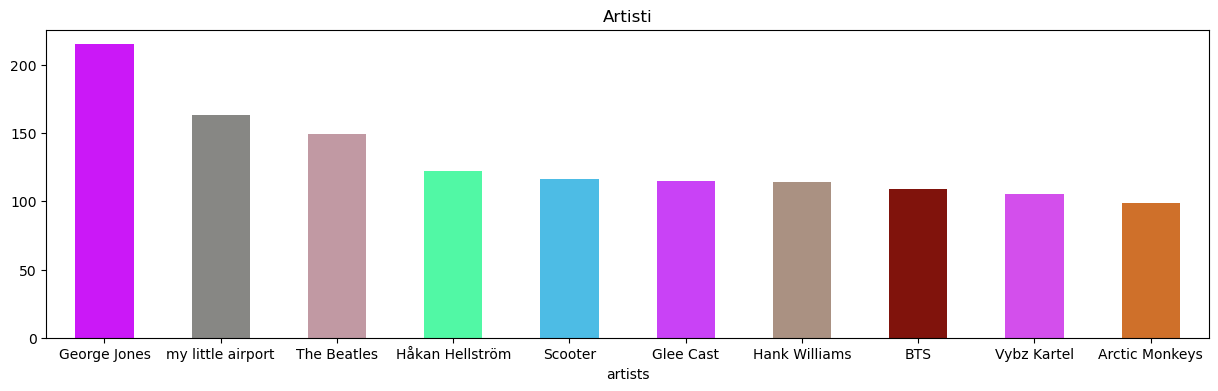

In [22]:
plot_bar("artists", 10, "Artisti")

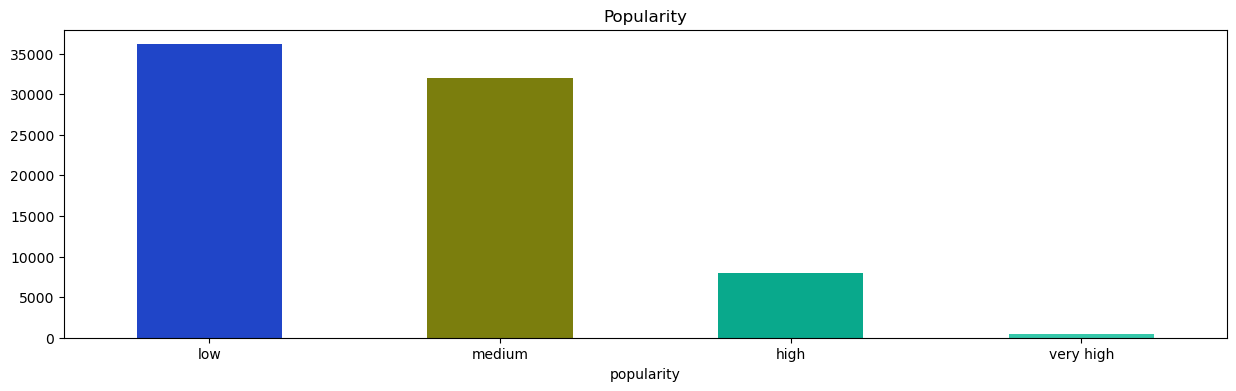

In [23]:
plot_bar('popularity',
         bins=[0, 35, 60, 80, 100],
         labels=['low', 'medium', 'high', 'very high'],
         title='Popularity')

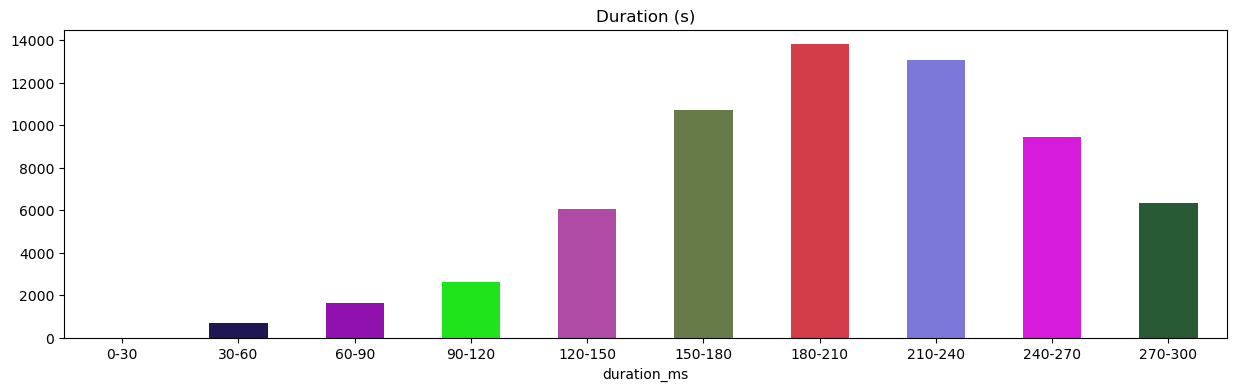

In [24]:
plot_bar('duration_ms',
         bins=[0, 30000, 60000, 90000, 120000, 150000, 180000, 210000, 240000, 270000, 300000],
         labels=['0-30', '30-60', '60-90', '90-120', '120-150', '150-180', '180-210', '210-240', '240-270', '270-300'],
         title='Duration (s)')

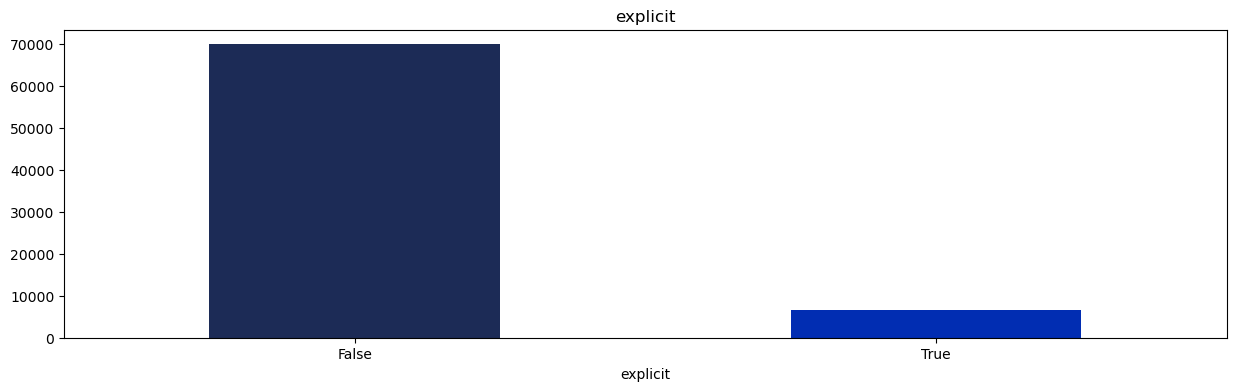

In [25]:
plot_bar("explicit", 2, "explicit")

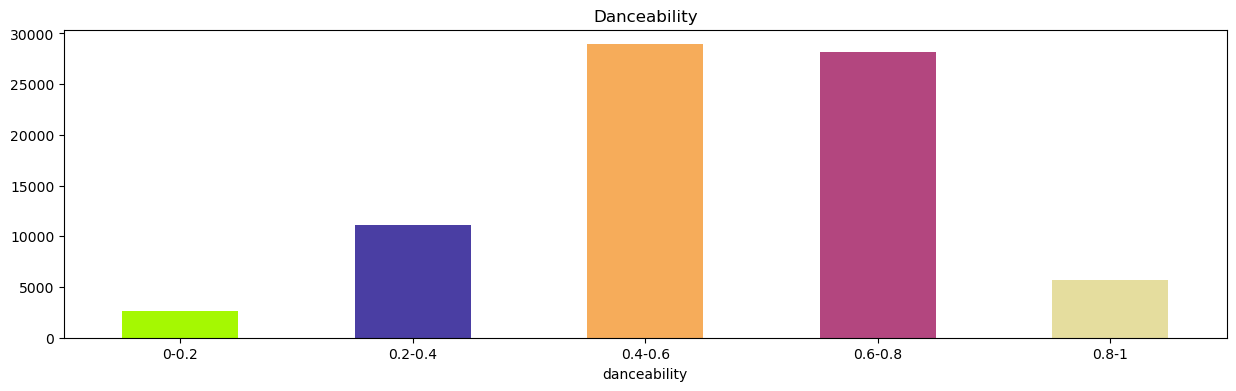

In [26]:
plot_bar('danceability',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Danceability')

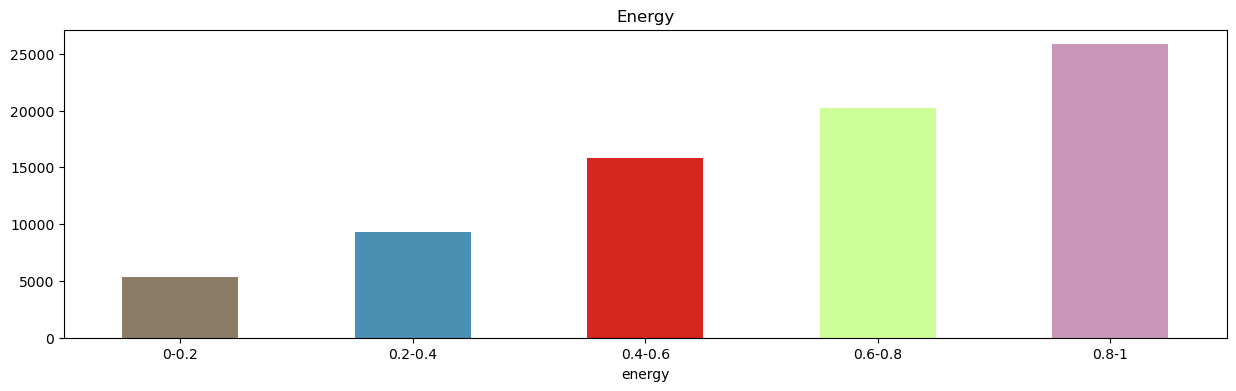

In [27]:
plot_bar('energy',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Energy')

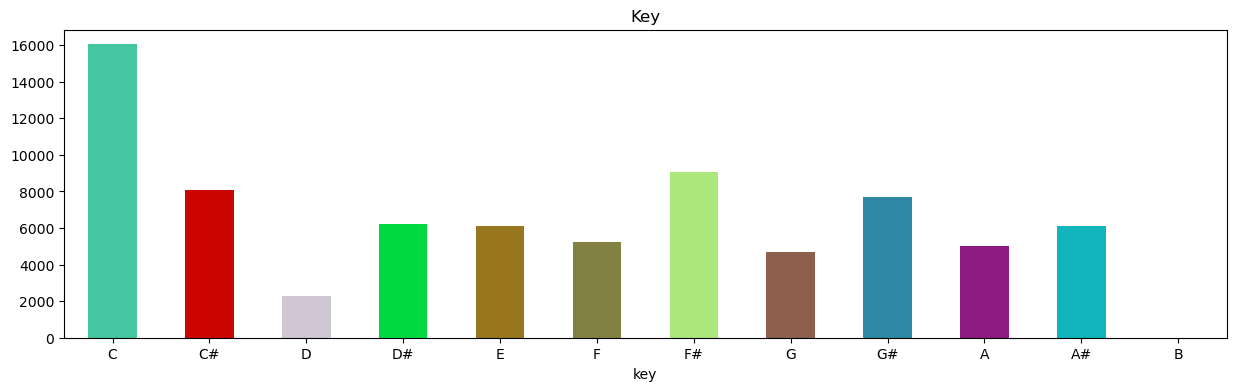

In [28]:
plot_bar('key',
         bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
         labels=['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B'],
         title='Key')

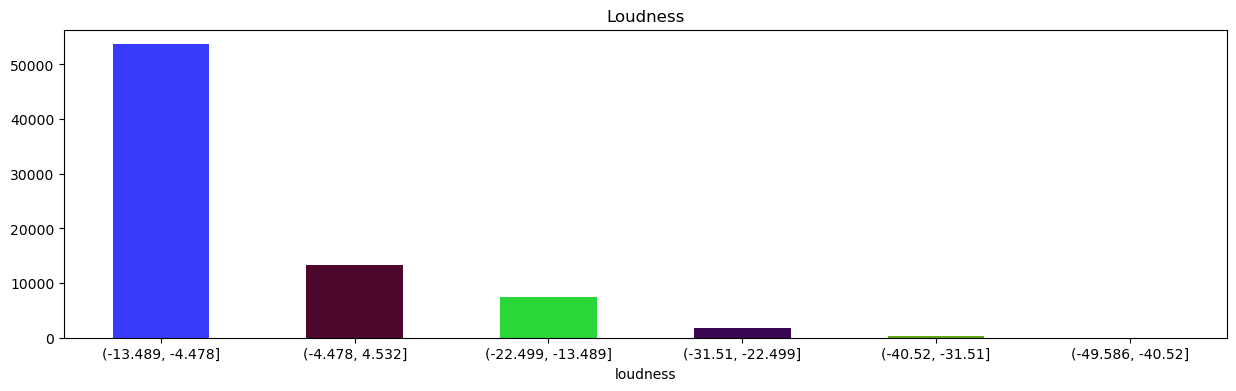

In [29]:
plot_bar('loudness',
         bins=6,
         title='Loudness')

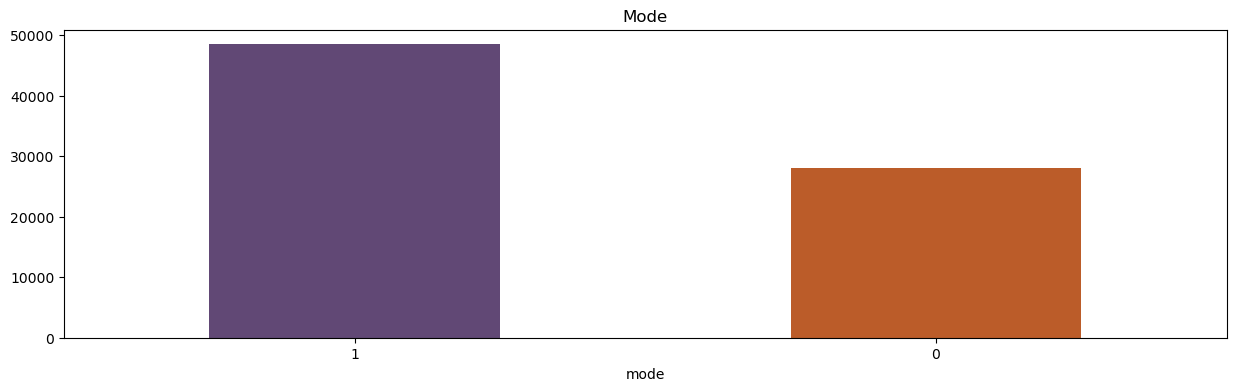

In [30]:
plot_bar("mode", 2, "Mode")

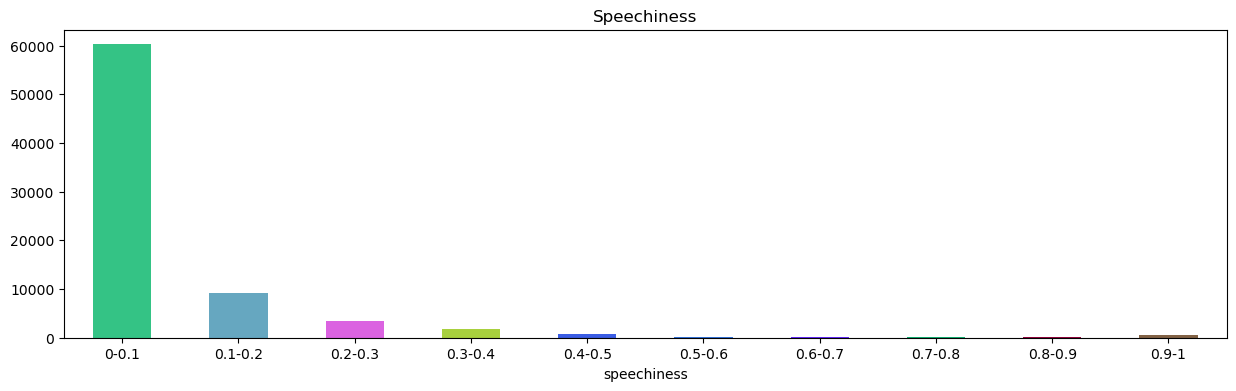

In [31]:
plot_bar('speechiness',
         bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
         labels=['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1'],
         title='Speechiness')

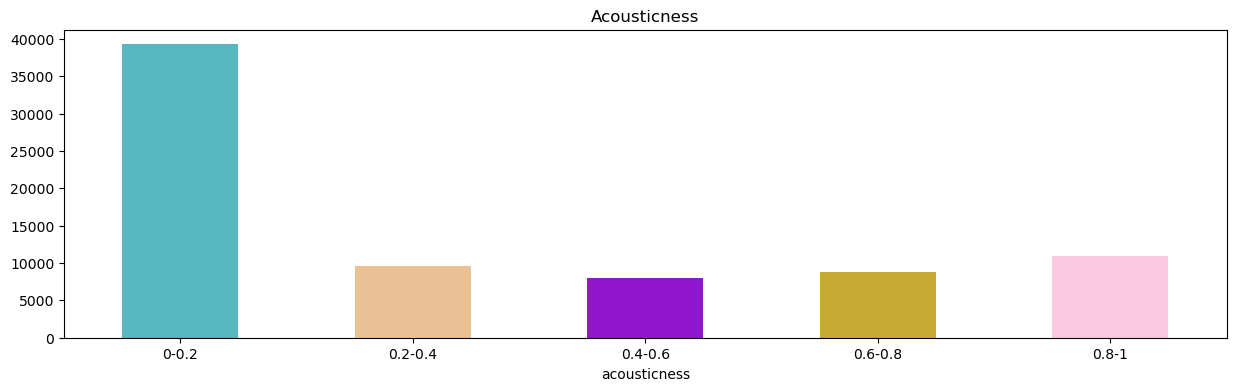

In [32]:
plot_bar('acousticness',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Acousticness')

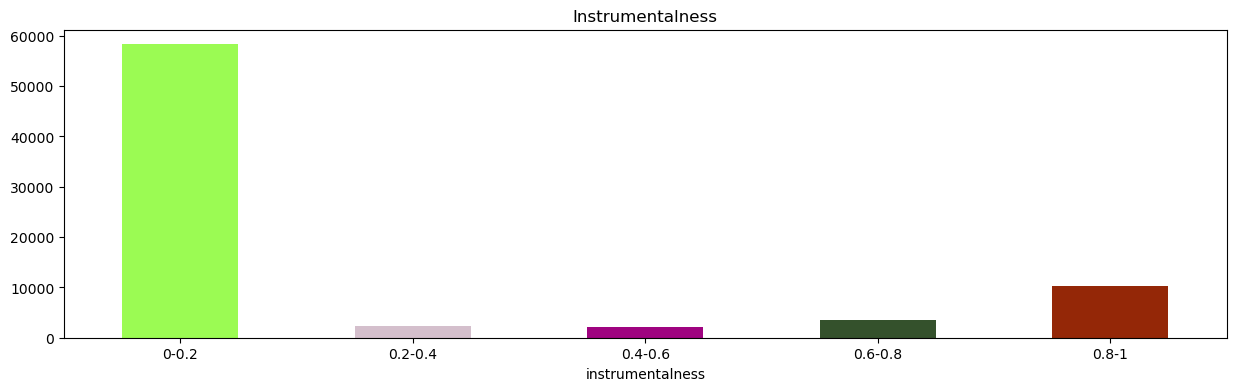

In [33]:
plot_bar('instrumentalness',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Instrumentalness')

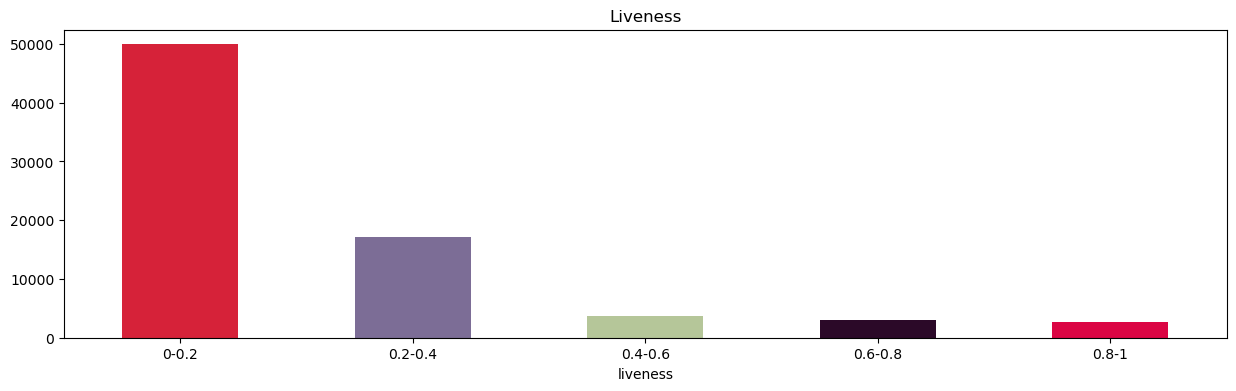

In [34]:
plot_bar('liveness',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Liveness')

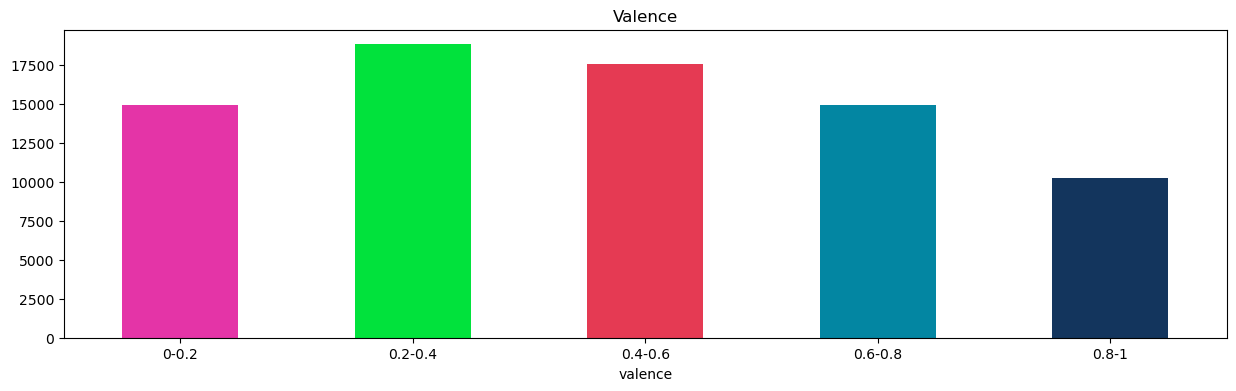

In [35]:
plot_bar('valence',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Valence')

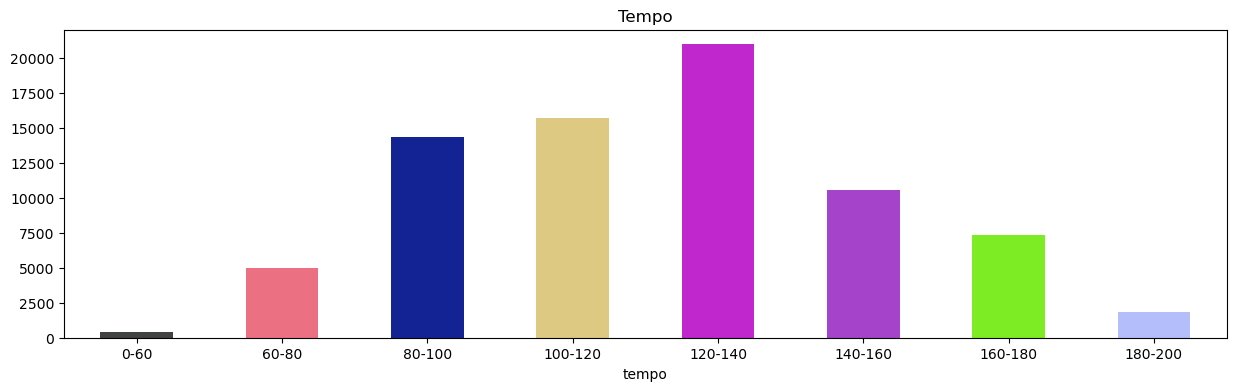

In [36]:
plot_bar('tempo',
         bins=[0, 60, 80, 100, 120, 140, 160, 180, 200],
         labels=['0-60', '60-80', '80-100', '100-120', '120-140', '140-160', '160-180', '180-200'],
         title='Tempo')

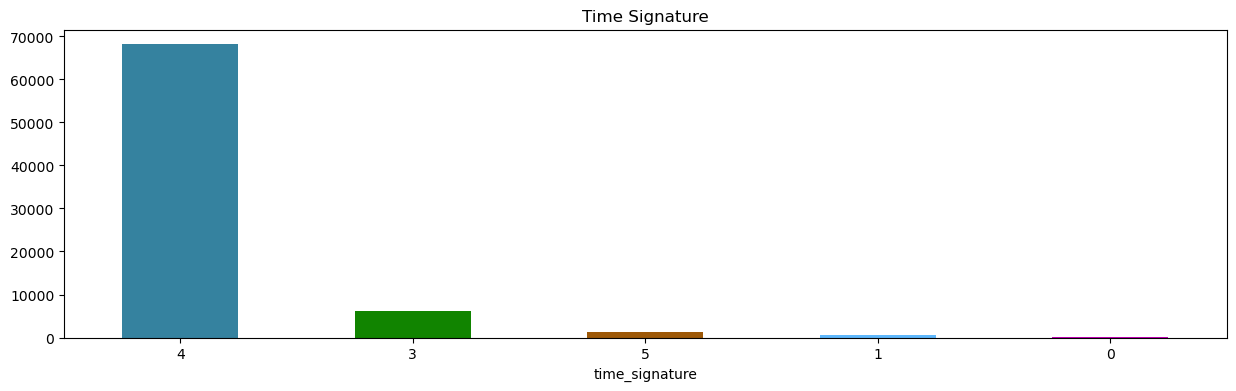

In [37]:
plot_bar("time_signature", 5, "Time Signature")

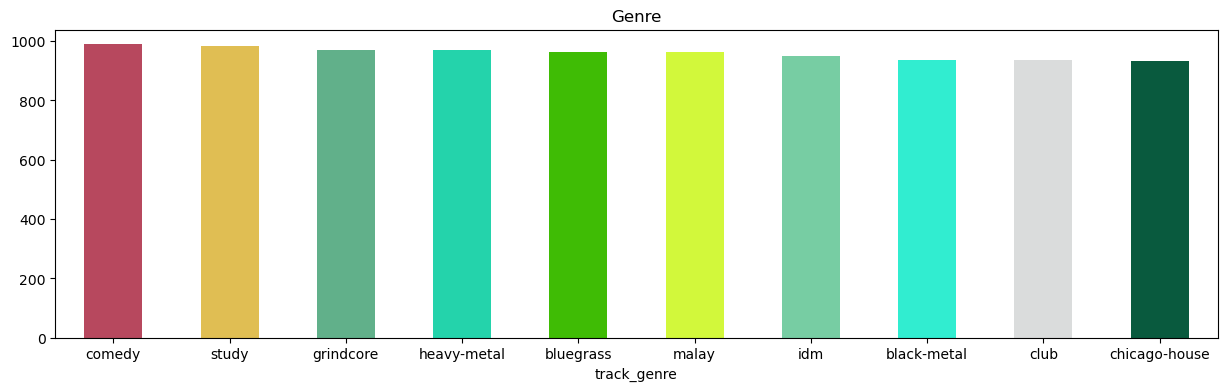

In [38]:
plot_bar("track_genre", 10, "Genre")

## Preparazione dei dati
testo preparazione

In [68]:
print('preparazione dati')

preparazione dati


## Preparazione del modello
testo modello

## Conclusioni
testo conclusione